In [7]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from mplsoccer import Pitch
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.metrics import accuracy_score, roc_auc_score,log_loss,brier_score_loss
from sklearn.metrics import roc_curve, auc




In [3]:
features_all = pd.read_csv("../data/features_2022_2023_final.csv")

In [4]:
features_train = features_all[['start_distance_to_goal', 'end_distance_to_goal', 'pass_length',
       'pass_angle', 'start_angle_to_goal', 'end_angle_to_goal',
       'start_distance_to_sideline', 'end_distance_to_sideline','teammates_behind',
       'teammates_beyond', 'opponents_beyond', 'opponents_behind',
       'opponents_between', 'packing', 'pressure_on_passer',
       'average_speed_of_teammates', 'average_speed_of_opponents',
       'opponents_nearby','teammates_nearby',"possession_xG_target"]]

### model 1

In [5]:
X_1 = features_train[["end_distance_to_goal","start_distance_to_sideline","end_angle_to_goal","pass_length","pressure_on_passer"]]
Y_1 = features_train[["possession_xG_target"]]

X_train_1,X_test_1,Y_train_1,Y_test_1 = train_test_split(X_1,Y_1,test_size=0.25,random_state=50)

train_data_1 = X_train_1.copy()
train_data_1['possession_xG_target'] = Y_train_1

logit_formula = "possession_xG_target ~ end_distance_to_goal + start_distance_to_sideline + end_angle_to_goal + pressure_on_passer"

model_roc_1 = smf.logit(logit_formula,data=train_data_1).fit()

model_roc_1.summary() 


Optimization terminated successfully.
         Current function value: 0.362378
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                            Logit Regression Results                            
================================================================================
Dep. Variable:     possession_xG_target   No. Observations:                55565
Model:                            Logit   Df Residuals:                    55560
Method:                             MLE   Df Model:                            4
Date:                  Fri, 23 May 2025   Pseudo R-squ.:                 0.03328
Time:                          19:44:22   Log-Likelihood:                -20136.
converged:                         True   LL-Null:                       -20829.
Covariance Type:              nonrobust   LLR p-value:                6.245e-299
==============================================================================================
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                     -0.1448      0.121     -1.196      0.232      -0.382       0.093
end_distance_to_goal          -0.0341      0.001    -24.655      0.000      -0.037      -0.031
start_distance_to_sideline     0.0202      0.001     13.972      0.000       0.017       0.023
end_angle_to_goal             -0.3065      0.029    -10.655      0.000      -0.363      -0.250
pressure_on_passer             0.2638      0.029      9.225      0.000       0.208       0.320
==============================================================================================
"""

In [8]:
test_data_1 = X_test_1.copy()
test_data_1['possession_xG_target'] = Y_test_1

y_pred_prob_1 = model_roc_1.predict(test_data_1)

from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(Y_test_1,y_pred_prob_1)
roc_auc_1 = auc(fpr, tpr)
brier_1  = brier_score_loss(Y_test_1, y_pred_prob_1)
logloss_1 = log_loss(Y_test_1, y_pred_prob_1)
print(f"ROC AUC :      {roc_auc_1:.4f}")
print(f"Logloss:{logloss_1:.4f}")
print(f"Brier Score:  {brier_1:.4f}")


ROC AUC :      0.6439
Logloss:0.3661
Brier Score:  0.1072


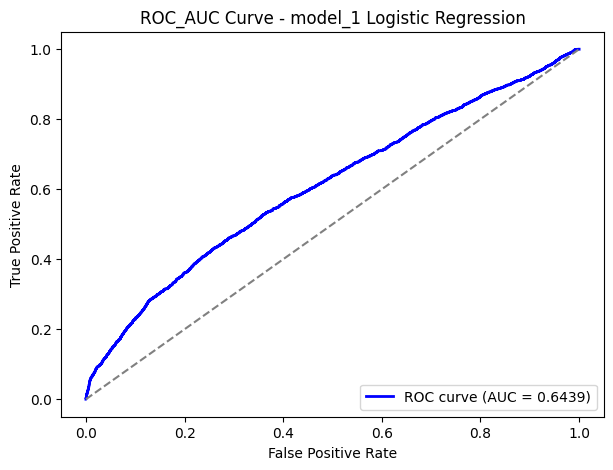

In [21]:
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc_1:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal reference line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC_AUC Curve - model_1 Logistic Regression')
plt.legend(loc="lower right")
plt.show()

## model 2

In [10]:
X_2 = features_train[[ 'pass_angle','start_angle_to_goal','end_angle_to_goal',"end_distance_to_sideline","average_speed_of_opponents","packing"]]
Y_2 = features_train["possession_xG_target"]

X_train_2,X_test_2,Y_train_2,Y_test_2 = train_test_split(X_2,Y_2,test_size=0.25,random_state=50)

train_data_2 = X_train_2.copy()
train_data_2['possession_xG_target'] = Y_train_2

model_logit_formula_2 = "possession_xG_target ~ pass_angle + end_distance_to_sideline + start_angle_to_goal + end_angle_to_goal + average_speed_of_opponents + packing"

model_roc_2 = smf.logit(model_logit_formula_2, data=train_data_2).fit(method='bfgs', maxiter=200)

model_roc_2.summary()


Optimization terminated successfully.
         Current function value: 0.359499
         Iterations: 34
         Function evaluations: 40
         Gradient evaluations: 40


<class 'statsmodels.iolib.summary.Summary'>
"""
                            Logit Regression Results                            
================================================================================
Dep. Variable:     possession_xG_target   No. Observations:                55565
Model:                            Logit   Df Residuals:                    55558
Method:                             MLE   Df Model:                            6
Date:                  Fri, 23 May 2025   Pseudo R-squ.:                 0.04096
Time:                          19:47:39   Log-Likelihood:                -19976.
converged:                         True   LL-Null:                       -20829.
Covariance Type:              nonrobust   LLR p-value:                     0.000
==============================================================================================
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                      0.3917      0.148      2.648      0.008       0.102       0.682
pass_angle                     0.0012      0.000     11.284      0.000       0.001       0.001
end_distance_to_sideline       0.0380      0.002     24.469      0.000       0.035       0.041
start_angle_to_goal           -0.1299      0.011    -11.842      0.000      -0.151      -0.108
end_angle_to_goal             -0.6664      0.031    -21.685      0.000      -0.727      -0.606
average_speed_of_opponents     0.2321      0.013     17.947      0.000       0.207       0.257
packing                       -0.0352      0.009     -3.810      0.000      -0.053      -0.017
==============================================================================================
"""

In [11]:
test_data_2 = X_test_2.copy()
test_data_2['possession_xG_target'] = Y_test_2
y_pred_prob_2 = model_roc_2.predict(test_data_2)
fpr, tpr, thresholds = roc_curve(Y_test_2,y_pred_prob_2)
roc_auc_2 = auc(fpr, tpr)
roc_auc_2 = roc_auc_score(Y_test_2, y_pred_prob_2)
brier_2  = brier_score_loss(Y_test_2, y_pred_prob_2)
logloss_2 = log_loss(Y_test_2, y_pred_prob_2)
print(f"ROC AUC :      {roc_auc_2:.4f}")
print(f"Logloss:{logloss_2:.4f}")
print(f"Brier Score:  {brier_2:.4f}")


ROC AUC :      0.6537
Logloss:0.3623
Brier Score:  0.1060


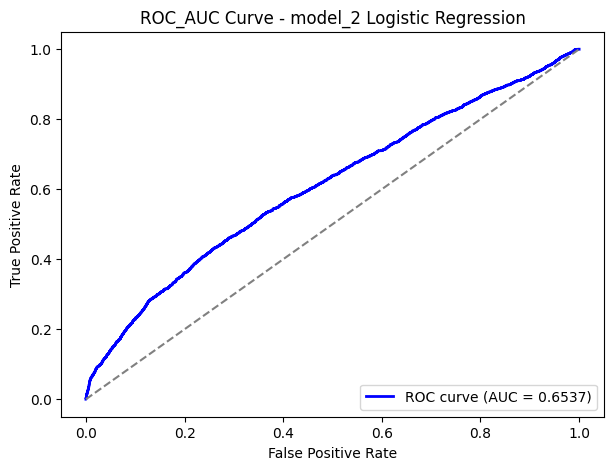

In [22]:
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc_2:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal reference line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC_AUC Curve - model_2 Logistic Regression')
plt.legend(loc="lower right")
plt.show()

## model 3

In [13]:
X_3 = features_train[["opponents_nearby","teammates_beyond","teammates_nearby"]]
Y_3 = features_train[["possession_xG_target"]]

X_train_3,X_test_3,Y_train_3,Y_test_3 = train_test_split(X_3,Y_3,test_size=0.25,random_state=50)

train_data_3 = X_train_3.copy()
train_data_3['possession_xG_target'] = Y_train_3

logit_formula_3 = "possession_xG_target ~ opponents_nearby + teammates_beyond + teammates_nearby"

model_roc_3 = smf.logit(logit_formula_3,data=train_data_3).fit()

model_roc_3.summary()


Optimization terminated successfully.
         Current function value: 0.369669
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                            Logit Regression Results                            
================================================================================
Dep. Variable:     possession_xG_target   No. Observations:                55565
Model:                            Logit   Df Residuals:                    55561
Method:                             MLE   Df Model:                            3
Date:                  Fri, 23 May 2025   Pseudo R-squ.:                 0.01383
Time:                          19:50:12   Log-Likelihood:                -20541.
converged:                         True   LL-Null:                       -20829.
Covariance Type:              nonrobust   LLR p-value:                1.555e-124
====================================================================================
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -1.3490      0.039    -34.313      0.000      -1.426      -1.272
opponents_nearby     0.0356      0.015      2.429      0.015       0.007       0.064
teammates_beyond    -0.1258      0.006    -21.871      0.000      -0.137      -0.115
teammates_nearby    -0.0553      0.027     -2.043      0.041      -0.108      -0.002
====================================================================================
"""

In [14]:
test_data_3 = X_test_3.copy()
test_data_3['possession_xG_target'] = Y_test_3
y_pred_prob_3 = model_roc_3.predict(test_data_3)
fpr, tpr, thresholds = roc_curve(Y_test_3,y_pred_prob_3)
roc_auc_3 = auc(fpr, tpr)
roc_auc_3 = roc_auc_score(Y_test_3, y_pred_prob_3)
brier_3  = brier_score_loss(Y_test_3, y_pred_prob_3)
logloss_3 = log_loss(Y_test_3, y_pred_prob_3)
print(f"ROC AUC :      {roc_auc_3:.4f}")
print(f"Logloss:{logloss_3:.4f}")
print(f"Brier Score:  {brier_3:.4f}")

ROC AUC :      0.6052
Logloss:0.3719
Brier Score:  0.1086


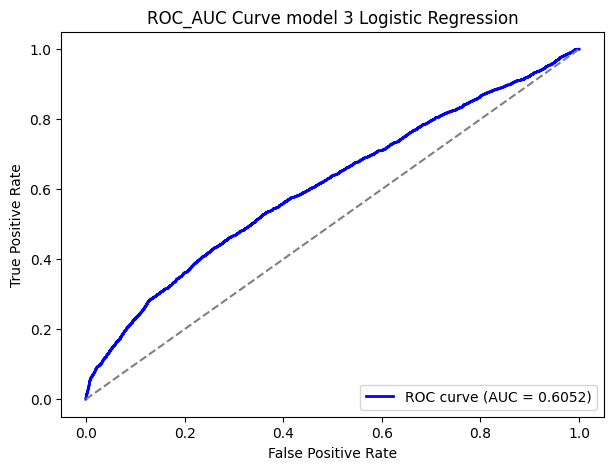

In [23]:
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc_3:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal reference line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC_AUC Curve model 3 Logistic Regression')
plt.legend(loc="lower right")
plt.show()

## model 4

In [16]:
X_4 = features_train[["opponents_beyond","teammates_beyond","opponents_between" ,"average_speed_of_teammates"]]
Y_4 = features_train[["possession_xG_target"]]

X_train_4,X_test_4,Y_train_4,Y_test_4 = train_test_split(X_4,Y_4,test_size=0.25,random_state=50)

logit_formula_4 = "possession_xG_target ~ opponents_beyond + teammates_beyond + opponents_between + average_speed_of_teammates"

train_data_4 = X_train_4.copy()
train_data_4['possession_xG_target'] = Y_train_4

model_roc_4 = smf.logit(logit_formula_4,data=train_data_4).fit()

model_roc_4.summary()


Optimization terminated successfully.
         Current function value: 0.366225
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                            Logit Regression Results                            
================================================================================
Dep. Variable:     possession_xG_target   No. Observations:                55565
Model:                            Logit   Df Residuals:                    55560
Method:                             MLE   Df Model:                            4
Date:                  Fri, 23 May 2025   Pseudo R-squ.:                 0.02302
Time:                          19:53:05   Log-Likelihood:                -20349.
converged:                         True   LL-Null:                       -20829.
Covariance Type:              nonrobust   LLR p-value:                2.967e-206
==============================================================================================
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                     -1.7183      0.059    -29.197      0.000      -1.834      -1.603
opponents_beyond              -0.0927      0.007    -12.732      0.000      -0.107      -0.078
teammates_beyond              -0.0538      0.007     -7.435      0.000      -0.068      -0.040
opponents_between              0.0486      0.005      9.540      0.000       0.039       0.059
average_speed_of_teammates     0.1836      0.014     13.259      0.000       0.156       0.211
==============================================================================================
"""

In [17]:
from sklearn.metrics import roc_curve, auc


test_data_4 = X_test_4.copy()
test_data_4['possession_xG_target'] = Y_test_4
y_pred_prob_4 = model_roc_4.predict(test_data_4)
fpr, tpr, thresholds = roc_curve(Y_test_4,y_pred_prob_4)
roc_auc_4 = auc(fpr, tpr)
brier_4  = brier_score_loss(Y_test_4, y_pred_prob_4)
logloss_4 = log_loss(Y_test_4, y_pred_prob_4)
print(f"ROC AUC:      {roc_auc_4:.4f}")
print(f"Logloss:{logloss_4:.4f}")
print(f"Brier Score:  {brier_4:.4f}")



ROC AUC:      0.6083
Logloss:0.3693
Brier Score:  0.1077


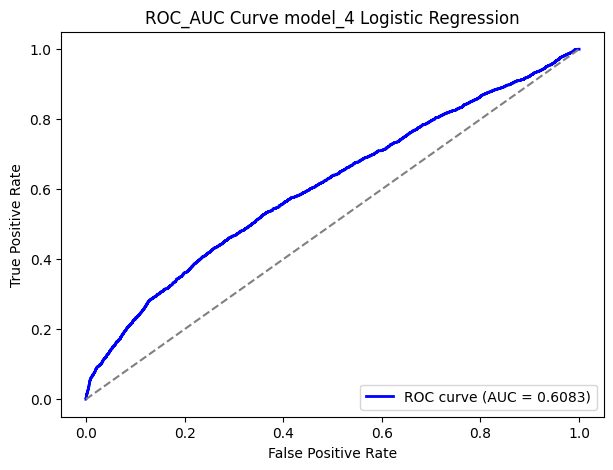

In [24]:
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc_4:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal reference line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC_AUC Curve model_4 Logistic Regression')
plt.legend(loc="lower right")
plt.show()

## model 5

In [25]:
X_5 = features_train[["start_distance_to_goal","pass_length","start_angle_to_goal","end_angle_to_goal","opponents_beyond","opponents_behind","teammates_behind"]]
Y_5 = features_train[["possession_xG_target"]]

X_train_5,X_test_5,Y_train_5,Y_test_5 = train_test_split(X_5,Y_5,test_size=0.25,random_state=50)

logit_formula_5 = "possession_xG_target ~ start_distance_to_goal + opponents_beyond + opponents_behind + start_angle_to_goal + end_angle_to_goal + teammates_behind"

train_data_5 = X_train_5.copy()
train_data_5['possession_xG_target'] = Y_train_5

model_roc_5 = smf.logit(logit_formula_5,data=train_data_5).fit()

model_roc_5.summary()

Optimization terminated successfully.
         Current function value: 0.360700
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                            Logit Regression Results                            
================================================================================
Dep. Variable:     possession_xG_target   No. Observations:                55565
Model:                            Logit   Df Residuals:                    55558
Method:                             MLE   Df Model:                            6
Date:                  Sat, 24 May 2025   Pseudo R-squ.:                 0.03776
Time:                          05:25:51   Log-Likelihood:                -20042.
converged:                         True   LL-Null:                       -20829.
Covariance Type:              nonrobust   LLR p-value:                     0.000
==========================================================================================
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  3.0707      0.470      6.531      0.000       2.149       3.992
start_distance_to_goal    -0.0336      0.002    -21.173      0.000      -0.037      -0.030
opponents_beyond          -0.2811      0.042     -6.733      0.000      -0.363      -0.199
opponents_behind          -0.2308      0.042     -5.520      0.000      -0.313      -0.149
start_angle_to_goal        0.1130      0.010     11.597      0.000       0.094       0.132
end_angle_to_goal         -0.3834      0.028    -13.530      0.000      -0.439      -0.328
teammates_behind           0.0437      0.007      6.168      0.000       0.030       0.058
==========================================================================================
"""

In [26]:
from sklearn.metrics import roc_curve, auc


test_data_5 = X_test_5.copy()
test_data_5['possession_xG_target'] = Y_test_5
y_pred_prob_5 = model_roc_5.predict(test_data_5)
fpr, tpr, thresholds = roc_curve(Y_test_5,y_pred_prob_5)
roc_auc_5 = auc(fpr, tpr)
brier_5  = brier_score_loss(Y_test_5, y_pred_prob_5)
logloss_5 = log_loss(Y_test_5, y_pred_prob_5)
print(f"ROC AUC:      {roc_auc_5:.4f}")
print(f"Logloss:{logloss_5:.4f}")
print(f"Brier Score:  {brier_5:.4f}")



ROC AUC:      0.6433
Logloss:0.3646
Brier Score:  0.1066


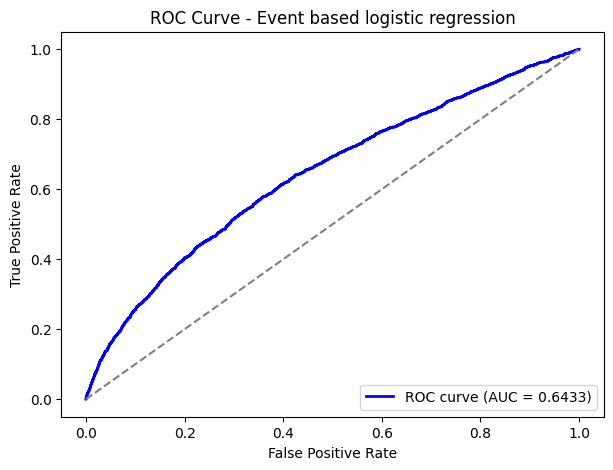

In [27]:
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc_5:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal reference line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Event based logistic regression')
plt.legend(loc="lower right")
plt.show()

### neural network

In [28]:
import pandas as pd
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [32]:
df_params_model_1 = pd.DataFrame(model_roc_1.params,columns=["value_model1_coeff"]).reset_index()
df_params_model_1.rename(columns={'index':'model1_coeff'},inplace = True)

df_params_model_2 = pd.DataFrame(model_roc_2.params,columns=["value_model2_coeff"]).reset_index()
df_params_model_2.rename(columns={'index':'model2_coeff'},inplace = True)

df_params_model_3 = pd.DataFrame(model_roc_3.params,columns=["value_model3_coeff"]).reset_index()
df_params_model_3.rename(columns={'index':'model3_coeff'},inplace = True)

df_params_model_4 = pd.DataFrame(model_roc_4.params,columns=["value_model4_coeff"]).reset_index()
df_params_model_4.rename(columns={'index':'model4_coeff'},inplace = True)

df_params_model_5 = pd.DataFrame(model_roc_5.params,columns=["value_model5_coeff"]).reset_index()
df_params_model_5.rename(columns={'index':'model5_coeff'},inplace = True)

In [30]:
# Reset indices
X_1_reset = X_1.reset_index(drop=True)
X_2_reset = X_2.reset_index(drop=True)
X_3_reset = X_3.reset_index(drop=True)
X_4_reset = X_4.reset_index(drop=True)
X_5_reset = X_5.reset_index(drop=True)

# Identify and remove overlapping columns from X_2
overlap_cols_2 = X_1.columns.intersection(X_2.columns)
X_2_dedup = X_2_reset.drop(columns=overlap_cols_2)

# Combine X_1 and X_2_dedup
df_features = pd.concat([X_1_reset, X_2_dedup], axis=1)

# Identify and remove overlapping columns from X_3
overlap_cols_3 = df_features.columns.intersection(X_3.columns)
X_3_dedup = X_3_reset.drop(columns=overlap_cols_3)

df_features = pd.concat([df_features, X_3_dedup], axis=1)


overlap_cols_4 = df_features.columns.intersection(X_4.columns)
X_4_dedup = X_4_reset.drop(columns=overlap_cols_4)


df_features = pd.concat([df_features,X_4_dedup],axis=1)

overlap_cols_5 = df_features.columns.intersection(X_5.columns)
X_5_dedup = X_5_reset.drop(columns = overlap_cols_5)

df_features = pd.concat([df_features,X_5_dedup],axis=1)

In [33]:
df_params_model_1 = df_params_model_1[df_params_model_1["model1_coeff"] != "Intercept"]
df_params_model_2 = df_params_model_2[df_params_model_2["model2_coeff"] != "Intercept"]
df_params_model_3 = df_params_model_3[df_params_model_3["model3_coeff"] != "Intercept"]
df_params_model_4 = df_params_model_4[df_params_model_4["model4_coeff"] != "Intercept"]
df_params_model_5 = df_params_model_5[df_params_model_5["model5_coeff"] != "Intercept"] 

In [34]:
beta1 = df_params_model_1.set_index('model1_coeff')['value_model1_coeff']
beta2 = df_params_model_2.set_index('model2_coeff')['value_model2_coeff']
beta3 = df_params_model_3.set_index('model3_coeff')['value_model3_coeff']
beta4 = df_params_model_4.set_index('model4_coeff')['value_model4_coeff']
beta5 = df_params_model_5.set_index('model5_coeff')['value_model5_coeff']

model1_features = X_1.copy()
model2_features = X_2.copy()
model3_features = X_3.copy()
model4_features = X_4.copy()
model5_features = X_5.copy()

df_features['z1'] = model1_features.mul(beta1,axis=1).sum(axis=1)
df_features['z2'] = model2_features.mul(beta2,axis=1).sum(axis=1)
df_features['z3'] = model3_features.mul(beta3,axis=1).sum(axis=1)
df_features['z4'] = model4_features.mul(beta4,axis=1).sum(axis=1)
df_features['z5'] = model5_features.mul(beta5,axis=1).sum(axis=1)

df_features["h1"] = 1 / (1 + np.exp(-df_features['z1']))
df_features["h2"] = 1 / (1 + np.exp(-df_features['z2']))
df_features["h3"] = 1 / (1 + np.exp(-df_features['z3']))
df_features["h4"] = 1 / (1 + np.exp(-df_features['z4']))
df_features["h5"] = 1 / (1 + np.exp(-df_features['z5']))

In [35]:
df_features

,end_distance_to_goal,start_distance_to_sideline,end_angle_to_goal,pass_length,pressure_on_passer,pass_angle,start_angle_to_goal,end_distance_to_sideline,average_speed_of_opponents,packing,...,z1,z2,z3,z4,z5,h1,h2,h3,h4,h5
0,37.799688,20.583784,4.516563,33.848021,0.000000,29.181967,7.509383,4.080000,3.055364,2,...,-2.257783,-3.154654,-0.880900,-0.397727,-5.617687,0.094680,0.040908,0.292991,0.401859,0.003620
1,36.779908,29.466667,5.623071,19.628846,0.777216,263.263568,5.664500,19.040000,2.346909,1,...,-2.177608,-2.922007,-0.593654,-0.287551,-5.343795,0.101779,0.051076,0.355797,0.428604,0.004755
2,45.617366,23.115916,4.844688,25.249707,0.483192,303.415445,6.916956,2.040000,2.942000,1,...,-2.446400,-3.023959,-0.971183,-0.722322,-5.631980,0.079702,0.046355,0.274645,0.326882,0.003569
3,27.381791,4.890691,3.842600,18.122987,0.193301,353.952501,4.463349,6.800000,2.067000,1,...,-1.961957,-1.996912,-0.341969,-0.181230,-4.812298,0.123255,0.119528,0.415331,0.454816,0.008064
4,34.491396,3.236637,5.025180,12.623368,0.080622,50.094026,5.039646,12.920000,1.748000,3,...,-2.630079,-3.149502,-0.845340,-0.918377,-5.842237,0.067228,0.041111,0.300411,0.285289,0.002894
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74082,12.853012,32.295396,4.234803,18.908474,0.550305,331.703371,5.160475,23.332090,2.798182,3,...,-0.938612,-1.648789,-0.306409,0.106574,-4.282422,0.281181,0.161273,0.423991,0.526618,0.013621
74083,30.892297,4.895193,4.119363,69.004274,0.018224,303.418442,5.953116,5.508966,2.900100,3,...,-2.212628,-2.363666,-0.397250,0.262850,-5.006028,0.098622,0.085986,0.401973,0.565337,0.006653
74084,24.602352,4.340426,3.785306,54.340338,0.453654,273.078354,3.787656,9.397648,0.732000,3,...,-1.792023,-2.253048,-0.145564,0.372057,-3.994605,0.142825,0.095087,0.463673,0.591956,0.018082
74085,30.759432,33.059552,3.677703,40.534009,1.157373,308.550757,5.255313,3.240568,2.840100,2,...,-1.203116,-2.037330,-0.794499,-0.175351,-3.955113,0.230921,0.115339,0.311203,0.456274,0.018796


In [36]:
df_features["possession_xG_target"] = features_all["possession_xG_target"]
df_features["id"] = features_all['id']

In [43]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, precision_score
import numpy as np
import random

# -------------------------------
# Set seed for reproducibility
# -------------------------------
def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(70) 

# -------------------------------
# 1. Load and preprocess data
# -------------------------------
X = df_features[['h1','h2','h3','h4','h5']].values

y = df_features['possession_xG_target'].values

# Train/test split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=50
)

# Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled  = scaler.transform(X_test_raw)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test_tensor  = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

# -------------------------------
# 2. Define the model
# -------------------------------
class SimplerNet(nn.Module):
    def __init__(self, input_dim):
        super(SimplerNet, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            # nn.Dropout(0.2),  # optional
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.model(x)

model_1 = SimplerNet(input_dim=X_train_tensor.shape[1])

# -------------------------------
# 3. Training setup
# -------------------------------
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model_1.parameters(), lr=0.008, weight_decay=1e-5)

n_epochs = 10000
# -------------------------------
# 4. Training loop
# -------------------------------
# Ensure grad mode is enabled
torch.set_grad_enabled(True)
for epoch in range(1, n_epochs+1):
    model_1.train()
    optimizer.zero_grad()

    outputs = model_1(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    # verify that loss requires grad
    assert loss.requires_grad, "Gradients are disabled on loss!"
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0 or epoch == 1:
        with torch.no_grad():
            train_probs = torch.sigmoid(outputs)
            train_preds = (train_probs >= 0.5).float()
            train_acc = (train_preds == y_train_tensor).float().mean().item()
        print(f"Epoch [{epoch}/{n_epochs}] - "
              f"Train Loss: {loss.item():.4f} | "
              f"Train Acc: {train_acc:.4f}")
# No disabling of grad here
# -------------------------------
model_1.eval()
with torch.no_grad():
    test_logits = model_1(X_test_tensor)
    test_probs = torch.sigmoid(test_logits).numpy()
    test_preds = (test_probs >= 0.5).astype(int)

# Metrics
acc       = accuracy_score(y_test_tensor.numpy(), test_preds)
fpr, tpr, thresholds = roc_curve(y_test_tensor.numpy(),test_preds)
auc       = roc_auc_score(y_test_tensor.numpy(), test_probs)
f1        = f1_score(y_test_tensor.numpy(), test_preds)
precision = precision_score(y_test_tensor.numpy(), test_preds)
logloss    = log_loss(y_test_tensor.numpy(), test_probs)
brier      = brier_score_loss(y_test_tensor.numpy(), test_probs)

print("\n--- Test Set Evaluation ---")
print(f"ROC_AUC:       {auc:.4f}")
print(f"Log Loss:     {logloss:.4f}")
print(f"Brier Score:  {brier:.4f}")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1 Score:  {f1:.4f}") 



Epoch [1/10000] - Train Loss: 0.7035 | Train Acc: 0.4360
Epoch [10/10000] - Train Loss: 0.5314 | Train Acc: 0.8713
Epoch [20/10000] - Train Loss: 0.4159 | Train Acc: 0.8760
Epoch [30/10000] - Train Loss: 0.3834 | Train Acc: 0.8760
Epoch [40/10000] - Train Loss: 0.3767 | Train Acc: 0.8760
Epoch [50/10000] - Train Loss: 0.3682 | Train Acc: 0.8760
Epoch [60/10000] - Train Loss: 0.3632 | Train Acc: 0.8760
Epoch [70/10000] - Train Loss: 0.3607 | Train Acc: 0.8760
Epoch [80/10000] - Train Loss: 0.3591 | Train Acc: 0.8760
Epoch [90/10000] - Train Loss: 0.3580 | Train Acc: 0.8760
Epoch [100/10000] - Train Loss: 0.3571 | Train Acc: 0.8760
Epoch [110/10000] - Train Loss: 0.3564 | Train Acc: 0.8760
Epoch [120/10000] - Train Loss: 0.3558 | Train Acc: 0.8760
Epoch [130/10000] - Train Loss: 0.3554 | Train Acc: 0.8760
Epoch [140/10000] - Train Loss: 0.3550 | Train Acc: 0.8760
Epoch [150/10000] - Train Loss: 0.3546 | Train Acc: 0.8760
Epoch [160/10000] - Train Loss: 0.3544 | Train Acc: 0.8760
Epoch [1

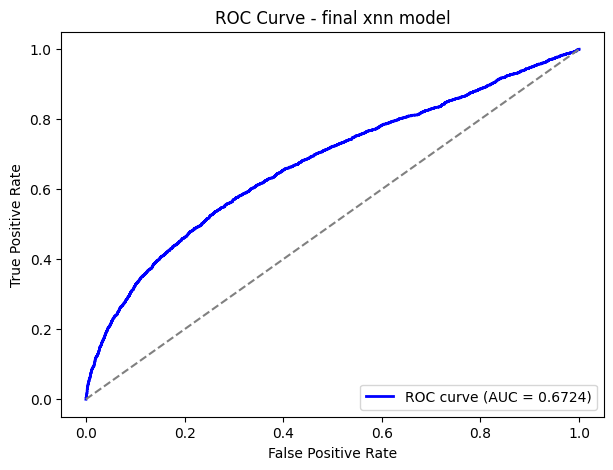

In [45]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(7,5))
fpr, tpr, thresholds = roc_curve(y_test_tensor.numpy(), test_probs)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal reference line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - final xnn model')
plt.legend(loc="lower right")
plt.show()